# PyMC Study
[PyMC公式ライブラリ](https://www.pymc.io/projects/docs/en/stable/installation.html)

## noteの流れ


グラフィカルモデルの定義
```python
with pm.Model() as model:

    # prior
    lambda0 = pm.Exponential("lambda0", 1.0)
    alpha = pm.Normal("alpha", 0, 1)

    # latent process
    y = pm.AR1("y", rho=theta, sigma=1, shape=T)

    # intensity
    lam = lambda0 * pm.math.exp(alpha * y)

    # likelihood
    k = pm.Poisson("k", mu=lam, observed=k_obs)
```

推論アルゴリズムの実行
```python
   trace = pm.sample(
        draws=2000, # 本番サンプル数
        tune=1000, # 捨てるサンプル数
        chains=4, # 独立なMCMCの数
        target_accept=0.9, # 採択する基準 
        return_inferencedata=True # Arvizで返してライブラリを使えるようにする
    )
```

推論の確認（必須）
```python
az.summary(trace) # 収束診断
az.plot_trace(trace) # トレースプロット
trace.sample_stats["diverging"].sum() # 発散　推奨値0
az.plot_energy(trace) # エネルギー診断
```

推論確認（推奨）
```python
az.plot_posterior(trace) # 事後分布の確認

with model: # 事後分布のチェック
    ppc = pm.sample_posterior_predictive(trace)
az.plot_ppc(ppc)

az.waic(trace)
az.loo(trace)

pm.compute_log_likelihood(trace) # 対数尤度の確認

az.plot_autocorr(trace, var_names=["y"]) # 自己相関　潜在変数など
```

In [1]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside jepx-data-analytics.")
PROJECT_DIR = REPO_ROOT / "Merton_Poisson_Lognormal_Model_Study_and_Negative_Binomial_Extension"
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import pymc as pm
import pytensor.tensor as pt
import arviz as az
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
#!pip install pymc pytensor
!pip show pymc
!pip show pytensor

Name: pymc
Version: 5.28.2
Summary: Probabilistic Programming in Python: Bayesian Modeling and Probabilistic Machine Learning with PyTensor
Home-page: http://github.com/pymc-devs/pymc
Author: 
Author-email: 
License: Apache License, Version 2.0
Location: C:\Users\h20s1\workspace\.venv\Lib\site-packages
Requires: arviz, cachetools, cloudpickle, numpy, pandas, pytensor, rich, scipy, threadpoolctl, typing-extensions
Required-by: 
Name: pytensor
Version: 2.38.2
Summary: Optimizing compiler for evaluating mathematical expressions on CPUs and GPUs.
Home-page: https://github.com/pymc-devs/pytensor
Author: 
Author-email: pymc-devs <pymc.devs@gmail.com>
License-Expression: BSD-3-Clause
Location: C:\Users\h20s1\workspace\.venv\Lib\site-packages
Requires: cons, etuples, filelock, logical-unification, miniKanren, numba, numpy, scipy, setuptools
Required-by: pymc


In [3]:
import shutil
print(shutil.which("g++"))

C:\msys64\ucrt64\bin\g++.EXE


# Modelの練習
## ベータ分布・ベルヌーイ分布
$$
X|p \sim \text{Be}(p)\ , \ p \sim \text{Beta}(\alpha , \beta)
$$
$p$の事後分布
$$
p|\vec{X}=\vec{x} \sim \text{Beta}\left(\sum_i x_i  + \alpha , N-\sum_i x_i + \beta\right)
$$

In [4]:
# 観測データ: 1=表, 0=裏
x_data = np.array([1, 0, 1, 1, 0 ])

with pm.Model() as beta_bernoulli_model:
    # 事前分布
    p = pm.Beta("p", alpha=2, beta=2)

    # 尤度
    # observed (観測された)
    x_obs = pm.Bernoulli("x_obs", p=p, observed=x_data)

    # MCMC
    trace = pm.sample(
        draws=2000, # 本番サンプル数
        tune=1000, # 捨てるサンプル数
        chains=4, # 独立なMCMCの数
        target_accept=0.9, # 採択する基準 
        return_inferencedata=True # Arvizで返してライブラリを使えるようにする
    )

az.summary(trace, var_names=["p"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 44 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.555,0.157,0.267,0.843,0.003,0.002,3067.0,3975.0,1.0


array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

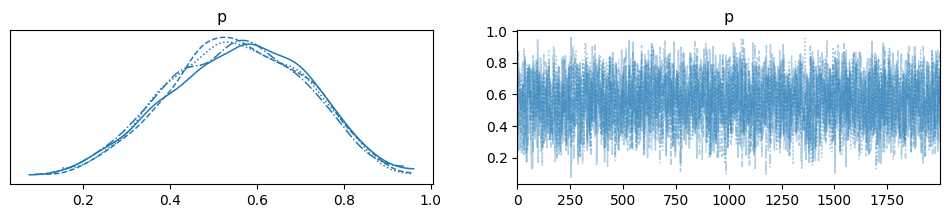

In [5]:
az.plot_trace(trace)

収束評価
- r_hat(収束基準) < 1.01
- ess_bulk(有効サンプルサイズ) > 1000
- traceが安定
- divergent(NUTS特有) = 0

# ガンマ分布・ポアソン分布
$$
X|\lambda \sim \text{Poisson} (\lambda)\ , \ \lambda \sim \text{Ga}(\alpha,\beta)
$$
$\lambda$の事後分布
$$
\lambda|\vec{X}=\vec{x} \sim \text{Poisson}\left(\sum_i x_i + \alpha , n + \beta\right)
$$

In [6]:
# 観測データ（カウント）
x_data = np.array([3, 2, 4, 3, 5])  # 合計17, n=5

# 事前分布パラメータ
alpha_prior = 2.0
beta_prior = 1.0   # rate

with pm.Model() as gamma_poisson_model:
    # 事前分布
    lam = pm.Gamma("lam", alpha=alpha_prior, beta=beta_prior)

    # 尤度
    x_obs = pm.Poisson("x_obs", mu=lam, observed=x_data)

    # MCMC
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        return_inferencedata=True
    )

# 結果表示
az.summary(trace, var_names=["lam"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lam]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 33 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lam,3.157,0.717,1.874,4.492,0.014,0.009,2687.0,3576.0,1.0


array([[<Axes: title={'center': 'lam'}>, <Axes: title={'center': 'lam'}>]],
      dtype=object)

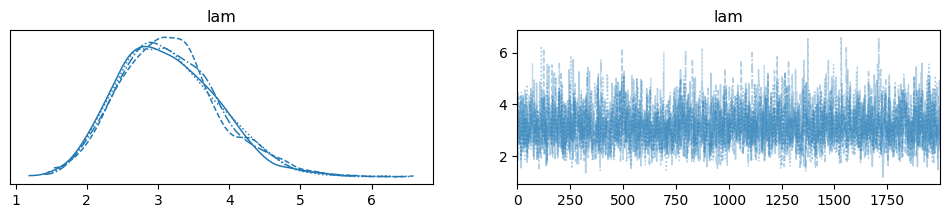

In [7]:
az.plot_trace(trace)

## 事後分布が$\delta$関数に近い場合（実験）

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 38 seconds.


       mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
theta   0.5  0.0     0.5      0.5        0.0      0.0    2832.0    4613.0   

       r_hat  
theta    1.0  


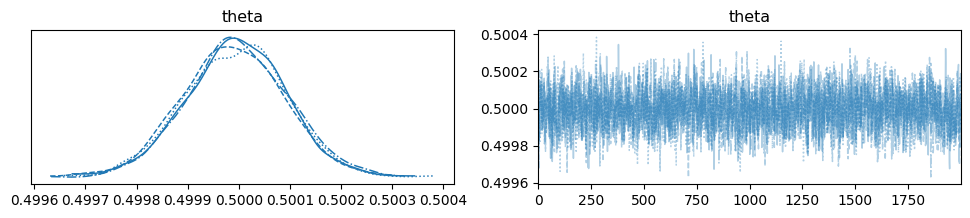

In [8]:
# =========================
# 観測データ（ほぼ確定させる）
# =========================
# 真の値を0.5とする
true_theta = 0.5

# ノイズを極小にする
sigma_obs = 1e-3

# データ数を増やすとさらに鋭くなる
x_data = np.random.normal(loc=true_theta, scale=sigma_obs, size=100)

# =========================
# モデル
# =========================
with pm.Model() as model:
    # 事前分布（広め）
    theta = pm.Normal("theta", mu=0, sigma=1)

    # 尤度（分散が極小）
    x_obs = pm.Normal("x_obs", mu=theta, sigma=sigma_obs, observed=x_data)

    # MCMC
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        return_inferencedata=True
    )

# =========================
# 結果
# =========================
print(az.summary(trace, var_names=["theta"]))

az.plot_trace(trace, var_names=["theta"])
plt.show()

## データ準備

In [9]:
# read csv
from pathlib import Path
csv_path = RAW_DATA_DIR / "default_counts/M.csv"
df = pd.read_csv(csv_path)

# set index to Year
df["Year"] = pd.to_datetime(df["Year"], format="%Y")
df = df.set_index("Year")
print("===to DatetimeIndex===")
print(type(df.index))
print("====DatetimeIndex====")

# normalization
df["SG_norm"] = df["D_SG"] / df["SG"] * 3000
df["IG_norm"] = df["D_IG"] / df["IG"] * 3000
df["ALL_norm"] = df["D_ALL"] / df["ALL"] * 3000

csv_path_para = PROJECT_DATA_DIR / "pre/init_para/init.csv"
csv_path_y = PROJECT_DATA_DIR / "pre/init_y/y.csv"

init_para = pd.read_csv(csv_path_para)
init_y = pd.read_csv(csv_path_y)
init_y["Year"] = pd.to_datetime(init_y["Year"])
init_y = init_y.set_index("Year")

init_para_fit = init_para[
    ["group", "lambda0_init", "alpha0_init", "theta_hat", "gamma_hat"]
]

===to DatetimeIndex===
<class 'pandas.DatetimeIndex'>
====DatetimeIndex====


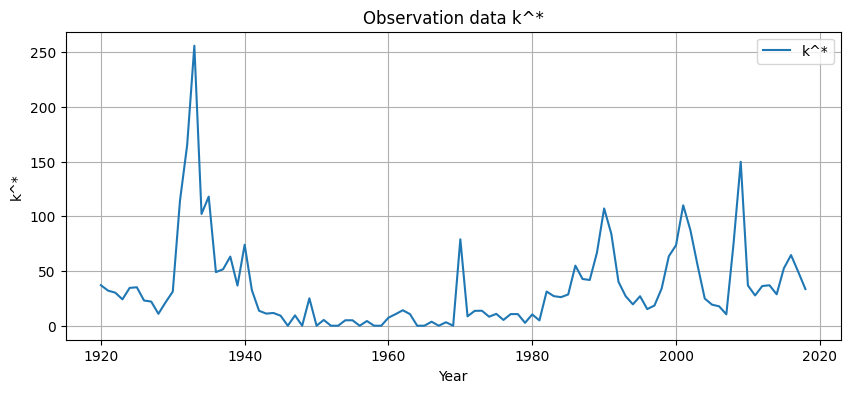

In [10]:
plt.figure(figsize=(10, 4))

plt.plot(df["ALL_norm"].index, df["ALL_norm"], label="k^*")
plt.title("Observation data k^*")
plt.xlabel("Year")
plt.ylabel("k^*")

plt.legend()
plt.grid(True)

plt.show()

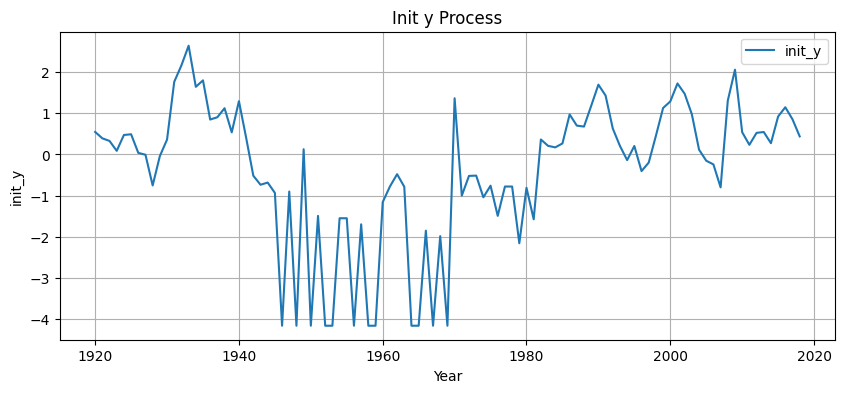

In [11]:
plt.figure(figsize=(10, 4))

plt.plot(init_y["ALL"].index, init_y["ALL"], label="init_y")
plt.title("Init y Process")
plt.xlabel("Year")
plt.ylabel("init_y")

plt.legend()
plt.grid(True)

plt.show()

In [12]:
init_para_fit[init_para_fit["group"] == "ALL"]

,group,lambda0_init,alpha0_init,theta_hat,gamma_hat
0,ALL,22.745634,0.918828,0.840086,0.508958


In [13]:
row_all = init_para_fit[init_para_fit["group"] == "ALL"].iloc[0]
lambda0_init = float(row_all["lambda0_init"])
alpha_init  = float(row_all["alpha0_init"])
theta_init    = float(row_all["theta_hat"])
gamma_init    = float(row_all["gamma_hat"])

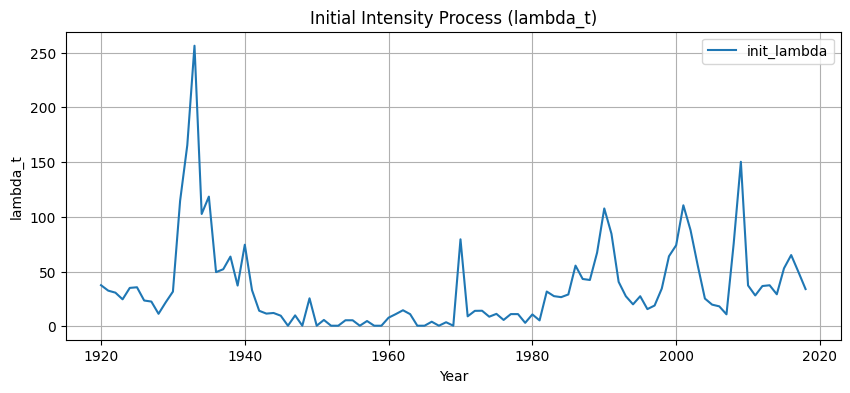

In [14]:
init_lambda = lambda0_init * np.exp(alpha_init * init_y["ALL"])
init_lambda = pd.DataFrame({
    "init_lambda": init_lambda
}, index=init_y["ALL"].index)

plt.figure(figsize=(10, 4))

plt.plot(init_lambda.index, init_lambda["init_lambda"], label="init_lambda")
plt.title("Initial Intensity Process (lambda_t)")
plt.xlabel("Year")
plt.ylabel("lambda_t")

plt.legend()
plt.grid(True)

plt.show()

```python
df["ALL_norm"] # 観測データk^*
init_y["ALL"] # マクロ要因の初期値

lambda0_init # lambda_0の初期値
alpha_init # alphaの初期値
theta_init # thetaの初期値
gamma_init # gammaの初期値
```

# モデル評価（WAIC , LFO）
$\text{GLM}$ VS 潜在変数モデル 
## ポアソン分布・正規分布($y_t$固定) ← GLM
$\eta_0 = \log{\lambda_0}$として
$$
X_t|(\lambda_0 , \alpha) , \vec{y}\sim   \text{Poisson}\left(\exp{(\eta_0 + \alpha y_t)}\right)
\ ,\ \eta_0 \sim \mathcal{N}(\mu_{\eta_0} , \sigma^2_{\eta_0})
\ ,\ \alpha \sim \mathcal{N^+}(\mu_{\alpha} , \sigma^2_{\alpha})
$$

ここでリンク関数（強度関数）を
$$
\lambda_t = \exp{(\eta_0 + \alpha y_t)}
$$

と置いた。

以下、
$\lambda_0 , \alpha $の事後分布$p(\lambda_0 , \alpha | \vec{k} , \vec{y})$は$\text{MCMC}$でシミュレーション

つまり
$$
p(\lambda_0 , \alpha | \vec{k} , \vec{y}) \propto p(\vec{k} | \eta_0 , \alpha , \vec{y}) p(\eta_0) p(\alpha)
$$

をMCMCを用いてシミュレーションする

※よく考えたら$y_t$に未来の情報を入れているのでGLMの制度がかなり良くなるのが必然。本番では、初期値を毎回作るべし

それでもGLMの方が予測精度が高い場合もある
- 予測器としては GLM が勝つ
- 機構モデルとしては EXP / POW に意味がある
- というすみわけにしていく必要がある

In [15]:
# =========================
# 1. データ準備
# =========================
k_data = df["ALL_norm"].to_numpy(dtype=float)
k_obs = np.rint(k_data).astype("int64")   # Poisson用に整数化
y_fixed = init_y["ALL"].to_numpy(dtype=float)

T = len(k_obs)

# 初期値・事前分布の中心
eta0_init = float(np.log(lambda0_init))
alpha_init = float(alpha_init)

# 事前分布の幅（まずは練習用に適度に設定）
sigma_eta0 = 0.5
sigma_alpha = 0.5

In [16]:
# =========================
# 2. PyMCモデル
# =========================
with pm.Model() as glm_poisson_model:
    # priors
    eta0 = pm.Normal(
        "eta0",
        mu=eta0_init,
        sigma=sigma_eta0
    )

    lambda0 = pm.Deterministic("lambda0", pm.math.exp(eta0))

    alpha = pm.TruncatedNormal(
        "alpha",
        mu=alpha_init,
        sigma=sigma_alpha,
        lower=0.0
    )

    # linear predictor
    log_mu = eta0 + alpha * y_fixed

    # Poisson mean
    mu = pm.Deterministic("mu", pm.math.exp(log_mu))

    # likelihood
    x = pm.Poisson(
        "x",
        mu=mu,
        observed=k_obs
    )

    # MCMC
    trace_glm = pm.sample(
        draws=500,
        tune=500,
        chains=4,
        cores=4,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eta0, alpha]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 31 seconds.


In [17]:
# =========================
# 3. 推定結果のサマリー
# =========================
print(eta0_init)
print(alpha_init)

summary = az.summary(trace_glm, var_names=["eta0", "lambda0" , "alpha"], round_to=4)
summary

3.1243732056434244
0.9188280249138177


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta0,3.0876,0.0251,3.0364,3.1305,0.0010,0.0007,649.4852,797.7001,1.0023
lambda0,21.9306,0.5488,20.8299,22.8843,0.0216,0.0150,649.4852,797.7001,1.0024
alpha,0.9405,0.0175,0.9083,0.9726,0.0007,0.0005,686.7018,864.2437,1.0027


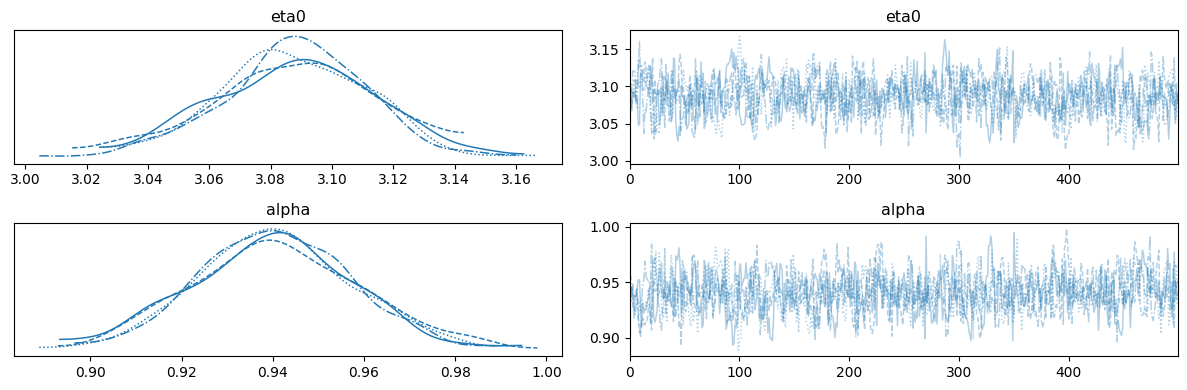

In [18]:
az.plot_trace(trace_glm, var_names=["eta0", "alpha"])
plt.tight_layout()
plt.show()

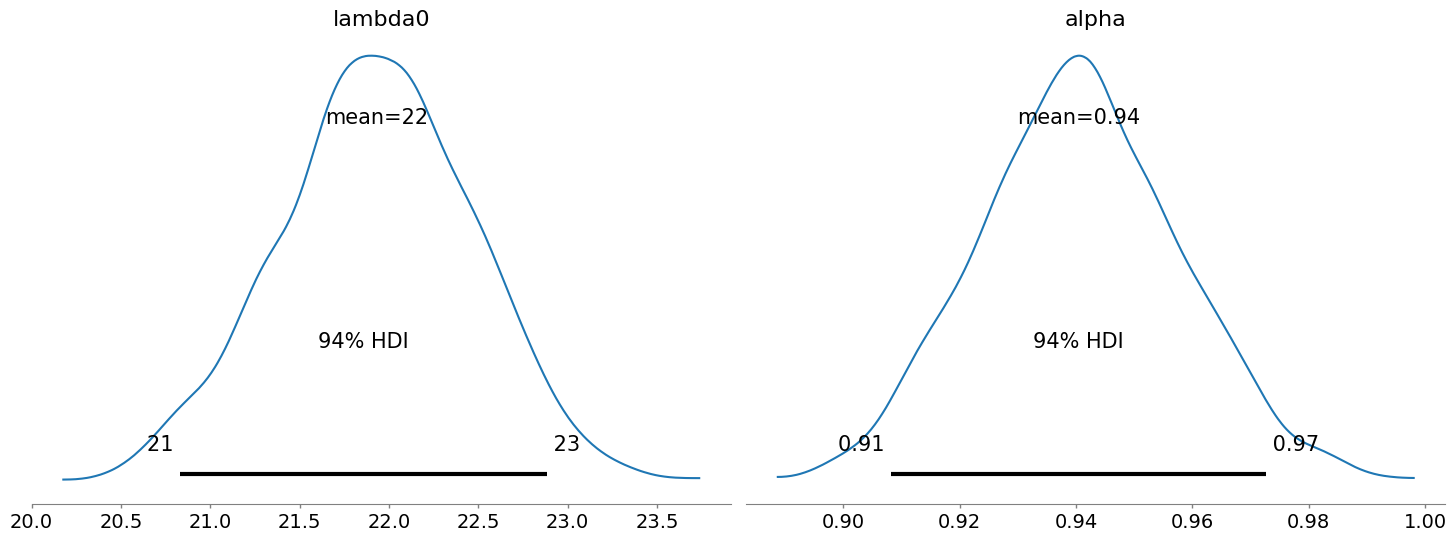

In [19]:
# 事後分布
az.plot_posterior(trace_glm, var_names=["lambda0" ,"alpha"])
plt.tight_layout()
plt.show()

In [20]:
# =========================
# 4. WAIC
# =========================
waic_glm = az.waic(trace_glm)
print(waic_glm)

Computed from 2000 posterior samples and 99 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -227.65     8.27
p_waic        0.13        -


### (重要)LFO
$$
\text{LFO} = \sum_{t=t_0}^{T-1} 
\log\left( \int d\theta \ p(x_{t+1} | \theta) p(\theta | \vec{x})  \right) \simeq \sum^{T-1}_{t=t_0}\left(\frac{1}{S} \sum^S_{s=1} p(x_{t+1} | \theta^{(s)})\right)
$$

```python
one_step_log_pred_density
```
$$
\log\left( \int d\theta \ p(x_{t+1} | \theta) p(\theta | \vec{x})  \right)
$$

In [21]:
# =========================
# 5. LFO
# =========================
import numpy as np
import pymc as pm
from scipy.special import gammaln, logsumexp

def fit_glm_mcmc(k_train, y_train, eta0_init, alpha_init,
                 sigma_eta0=0.5, sigma_alpha=0.5,
                 draws=1000, tune=1000, chains=2, cores=2,
                 random_seed=42):
    with pm.Model() as model:
        eta0 = pm.Normal("eta0", mu=eta0_init, sigma=sigma_eta0)
        alpha = pm.TruncatedNormal(
            "alpha",
            mu=alpha_init,
            sigma=sigma_alpha,
            lower=0.0
        )

        mu = pm.math.exp(eta0 + alpha * y_train)
        x = pm.Poisson("x", mu=mu, observed=k_train)

        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=0.9,
            random_seed=random_seed,
            return_inferencedata=True
        )
    return idata

In [22]:
def one_step_log_pred_density(idata, k_next, y_next):
    eta0_s = idata.posterior["eta0"].values.reshape(-1)
    alpha_s = idata.posterior["alpha"].values.reshape(-1)

    mu_next = np.exp(eta0_s + alpha_s * y_next)

    # 各 posterior sample ごとの log p(k_next | theta_s)
    logp_s = k_next * np.log(mu_next) - mu_next - gammaln(k_next + 1)

    # posterior predictive density の対数:
    # log( mean_s p(k_next | theta_s) )
    return logsumexp(logp_s) - np.log(len(logp_s))

In [23]:
k_data = df["ALL_norm"].to_numpy(dtype=float)
k_obs = np.rint(k_data).astype("int64")
y_fixed = init_y["ALL"].to_numpy(dtype=float)

eta0_init = float(np.log(lambda0_init))
alpha_init = float(alpha_init)

t0 = 30   # 最初の学習長。例
lfo_scores = []

for t in range(t0, len(k_obs) - 1):
    k_train = k_obs[:t]
    y_train = y_fixed[:t]

    k_next = k_obs[t]
    y_next = y_fixed[t]

    idata_t = fit_glm_mcmc(
        k_train=k_train,
        y_train=y_train,
        eta0_init=eta0_init,
        alpha_init=alpha_init,
        draws=1000,
        tune=1000,
        chains=2,
        cores=2,
        random_seed=42
    )

    lpd_t = one_step_log_pred_density(idata_t, k_next, y_next)
    lfo_scores.append(lpd_t)

lfo_total = np.sum(lfo_scores)
print("LFO total =", lfo_total)
print("n_folds   =", len(lfo_scores))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 35 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 21 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha]


...

C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 18 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 29 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


LFO total = -148.3703817074654
n_folds   = 68


In [24]:
print("LFO total =", lfo_total)
print("n_folds   =", len(lfo_scores))
print("LFO mean  =", lfo_total / len(lfo_scores)) # 一回当たりの予測精度平均

LFO total = -148.3703817074654
n_folds   = 68
LFO mean  = -2.181917378050962


In [25]:
lfo_scores

[np.float64(-0.46286616839352224),
 np.float64(-1.7784205616881401),
 np.float64(-0.4524877915136205),
 np.float64(-0.4522933922377126),
 np.float64(-1.7587700578381007),
 np.float64(-1.759715588267226),
 np.float64(-0.4401825392085863),
 np.float64(-1.6697472210851565),
 np.float64(-0.442634556736623),
 np.float64(-0.4363673029499111),
 np.float64(-1.9256337016548208),
 np.float64(-2.1573672848157575),
 np.float64(-2.264960438259701),
 np.float64(-2.1602036786826115),
 np.float64(-0.4317811826951914),
 np.float64(-0.4312421756356466),
 np.float64(-1.6509452260270212),
 np.float64(-0.43031960845079986),
 np.float64(-1.5216117388230117),
 np.float64(-0.42387924763812634),
 np.float64(-3.132486642346959),
 np.float64(-2.0645101990187564),
 np.float64(-2.282779360519182),
 np.float64(-2.2763194553356314),
 np.float64(-1.982195915559327),
 np.float64(-2.145318552345251),
 np.float64(-1.7593006961917164),
 np.float64(-2.1576723275973606),
 np.float64(-2.1562372235293044),
 np.float64(-1.508

## ポアソン分布・正規分布($y_t$相関なし)　←　潜在変数モデル
$\eta_0 = \log{\lambda_0}$として
$$
X_t|(\lambda_0 , \alpha) , \vec{y}\sim   \text{Poisson}\left(\exp{(\eta_0 + \alpha y_t)}\right)
\ ,\ \eta_0 \sim \mathcal{N}(\mu_{\eta_0} , \sigma^2_{\eta_0})
\ ,\ \alpha \sim \mathcal{N^+}(\mu_{\alpha} , \sigma^2_{\alpha})
\ , \ y_t \sim \mathcal{N}(0 , 1)
$$
$y_t$は**潜在変数**であり、推定対象になる

> 潜在変数モデルは観測できない変数が入っている

In [25]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# =========================
# 1. データ準備
# =========================
k_data = df["ALL_norm"].to_numpy(dtype=float)
k_obs = np.rint(k_data).astype("int64")
T = len(k_obs)

eta0_init = float(np.log(lambda0_init))
alpha_init = float(alpha_init)

y_init = init_y["ALL"].to_numpy(dtype=float)

# 事前分布の幅
sigma_eta0 = 0.5
sigma_alpha = 0.5

# =========================
# 2. latent y モデル
# =========================
with pm.Model() as latent_y_model:
    # ---- priors ----
    eta0 = pm.Normal(
        "eta0",
        mu=eta0_init,
        sigma=sigma_eta0
    )

    alpha = pm.TruncatedNormal(
        "alpha",
        mu=alpha_init,
        sigma=sigma_alpha,
        lower=0.0
    )

    # ---- latent states ----
    y = pm.Normal(
        "y",
        mu=0.0,
        sigma=1.0,
        shape=T,
        initval=y_init
    )

    # ---- mean ----
    mu = pm.Deterministic(
        "mu",
        pm.math.exp(eta0 + alpha * y)
    )

    # ---- likelihood ----
    x = pm.Poisson(
        "x",
        mu=mu,
        observed=k_obs
    )

    # ---- MCMC ----
    idata_latent = pm.sample(
        draws=4000,
        tune=4000,
        chains=4,
        cores=4,
        target_accept=0.99,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eta0, alpha, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 77 seconds.


In [26]:
summary_main = az.summary(
    idata_latent,
    var_names=["eta0", "alpha"],
    round_to=4
)
summary_main

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta0,2.8494,0.1385,2.5870,3.1029,0.0059,0.0027,558.8690,1129.0257,1.0034
alpha,1.4089,0.1217,1.1859,1.6359,0.0037,0.0019,1068.0746,2589.9823,1.0080


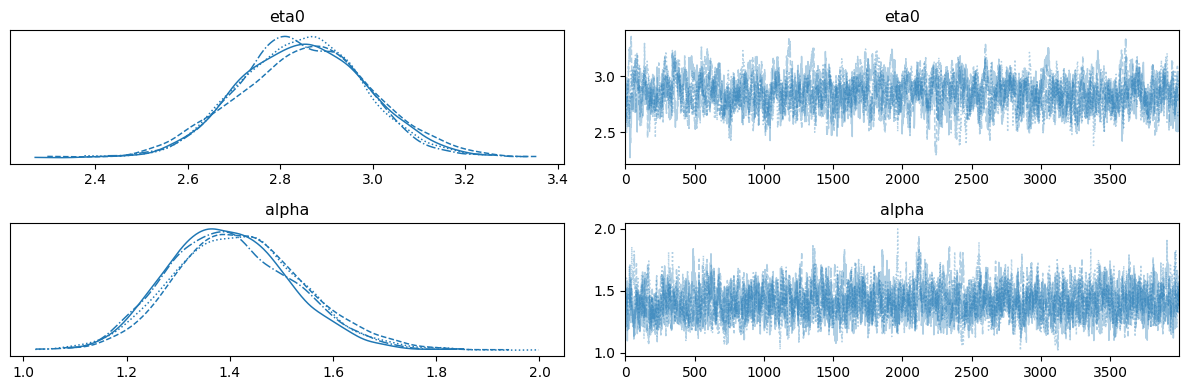

In [27]:
az.plot_trace(idata_latent, var_names=["eta0", "alpha"])
plt.tight_layout()
plt.show()

In [28]:
print(idata_latent.posterior["y"])

<xarray.DataArray 'y' (chain: 4, draw: 4000, y_dim_0: 99)> Size: 13MB
array([[[0.40620018, 0.55053296, 0.53093954, ..., 1.14108505,
         0.83231467, 0.58811487],
        [0.63000678, 0.53468396, 0.37644941, ..., 1.19509607,
         0.8093626 , 0.67617718],
        [0.7106188 , 0.41175372, 0.42824991, ..., 0.91429912,
         0.7529753 , 0.36487958],
        ...,
        [0.68815176, 0.31399891, 0.36264642, ..., 0.88273332,
         0.86989693, 0.80664957],
        [0.68438712, 0.59892331, 0.64658826, ..., 1.14658358,
         0.87035881, 0.68409374],
        [0.81168788, 0.34898759, 0.39931013, ..., 1.01836836,
         0.95342339, 0.6040743 ]],

       [[0.77344234, 0.64006643, 0.37773851, ..., 1.04617283,
         1.0015755 , 0.80328968],
        [0.636705  , 0.61919034, 0.64648794, ..., 1.12021135,
         0.78495276, 0.51703436],
        [0.68484058, 0.53000888, 0.38190606, ..., 1.00357221,
         0.93050745, 0.66612337],
...
        [0.46103823, 0.31066415, 0.19577353, ..

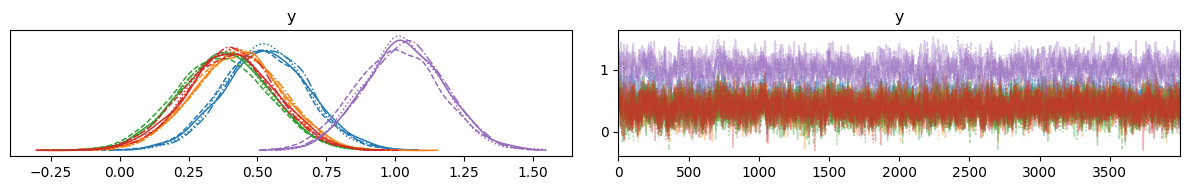

In [29]:
az.plot_trace(
    idata_latent,
    var_names=["y"],
    coords={"y_dim_0": [0, 1, 2, 10, 20]}
)
plt.tight_layout()
plt.show()

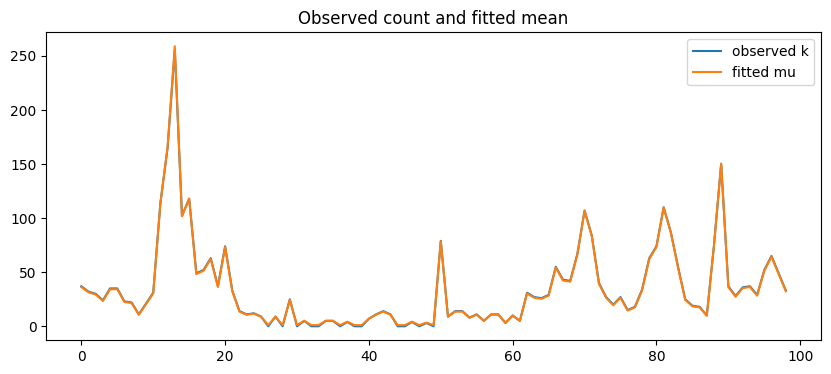

In [30]:
eta0_hat = idata_latent.posterior["eta0"].mean().item()
alpha_hat = idata_latent.posterior["alpha"].mean().item()
y_hat = idata_latent.posterior["y"].mean(dim=("chain", "draw")).values

mu_hat = np.exp(eta0_hat + alpha_hat * y_hat)

plt.figure(figsize=(10, 4))
plt.plot(k_obs, label="observed k")
plt.plot(mu_hat, label="fitted mu")
plt.legend()
plt.title("Observed count and fitted mean")
plt.show()

In [31]:
import numpy as np
import pymc as pm
from scipy.special import gammaln, logsumexp

def fit_latent_y_glm_mcmc(
    k_train,
    eta0_init,
    alpha_init,
    y_init=None,
    sigma_eta0=0.5,
    sigma_alpha=0.5,
    draws=1000,
    tune=1000,
    chains=2,
    cores=2,
    target_accept=0.9,
    random_seed=42,
):
    """
    学習データ x_{1:t} に対して
    p(eta0, alpha, y_{1:t} | x_{1:t})
    のMCMCサンプルを返す。
    """
    k_train = np.asarray(k_train, dtype="int64")
    T_train = len(k_train)

    if y_init is None:
        y_init = np.zeros(T_train, dtype=float)
    else:
        y_init = np.asarray(y_init, dtype=float)
        if len(y_init) != T_train:
            raise ValueError("y_init の長さが k_train と一致していません。")

    with pm.Model() as model:
        # priors
        eta0 = pm.Normal("eta0", mu=eta0_init, sigma=sigma_eta0)

        alpha = pm.TruncatedNormal(
            "alpha",
            mu=alpha_init,
            sigma=sigma_alpha,
            lower=0.0,
        )

        # latent states
        y = pm.Normal(
            "y",
            mu=0.0,
            sigma=1.0,
            shape=T_train,
            initval=y_init,
        )

        # likelihood
        mu = pm.math.exp(eta0 + alpha * y)
        x = pm.Poisson("x", mu=mu, observed=k_train)

        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=target_accept,
            random_seed=random_seed,
            return_inferencedata=True,
        )

    return idata

In [32]:
def one_step_log_pred_density_latent_y(
    idata,
    k_next,
    n_inner=20,
    random_seed=42,
):
    """
    1-step ahead の
    log p(x_{t+1} | x_{1:t})
    を Monte Carlo で近似する。

    今回は y_{t+1} も未知なので、
    y_{t+1} ~ N(0,1) を内側で積分する。
    """
    rng = np.random.default_rng(random_seed)

    eta0_s = idata.posterior["eta0"].values.reshape(-1)
    alpha_s = idata.posterior["alpha"].values.reshape(-1)

    S = len(eta0_s)

    # 各 posterior sample s に対して
    # y_next を n_inner 個ずつサンプル
    y_next_sr = rng.normal(loc=0.0, scale=1.0, size=(S, n_inner))

    # mu_{s,r} = exp(eta0_s + alpha_s * y_next_sr)
    mu_sr = np.exp(eta0_s[:, None] + alpha_s[:, None] * y_next_sr)

    # log p(k_next | eta0_s, alpha_s, y_next_sr)
    logp_sr = k_next * np.log(mu_sr) - mu_sr - gammaln(k_next + 1)

    # 全サンプル平均:
    # log [ (1/(S*n_inner)) sum_{s,r} p(k_next | eta0_s, alpha_s, y_next_sr) ]
    lpd_t = logsumexp(logp_sr.ravel()) - np.log(S * n_inner)

    return lpd_t

In [33]:
def compute_lfo_latent_y_glm(
    k_obs,
    eta0_init,
    alpha_init,
    y_init_full=None,
    t0=30,
    sigma_eta0=0.5,
    sigma_alpha=0.5,
    draws=1000,
    tune=1000,
    chains=2,
    cores=2,
    target_accept=0.9,
    n_inner=20,
    random_seed=42,
):
    """
    latent y_t を持つ Poisson GLM の LFO を計算する。

    Returns
    -------
    lfo_scores : list of float
        各 fold の log predictive density
    lfo_total : float
        その総和
    """
    k_obs = np.asarray(k_obs, dtype="int64")
    T = len(k_obs)

    if y_init_full is None:
        y_init_full = np.zeros(T, dtype=float)
    else:
        y_init_full = np.asarray(y_init_full, dtype=float)
        if len(y_init_full) != T:
            raise ValueError("y_init_full の長さが k_obs と一致していません。")

    lfo_scores = []

    for t in range(t0, T - 1):
        k_train = k_obs[:t]
        k_next = k_obs[t]

        y_init_train = y_init_full[:t]

        idata_t = fit_latent_y_glm_mcmc(
            k_train=k_train,
            eta0_init=eta0_init,
            alpha_init=alpha_init,
            y_init=y_init_train,
            sigma_eta0=sigma_eta0,
            sigma_alpha=sigma_alpha,
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=target_accept,
            random_seed=random_seed,
        )

        lpd_t = one_step_log_pred_density_latent_y(
            idata=idata_t,
            k_next=k_next,
            n_inner=n_inner,
            random_seed=random_seed + t,
        )

        lfo_scores.append(lpd_t)

    lfo_total = float(np.sum(lfo_scores))
    return lfo_scores, lfo_total

In [34]:
k_data = df["ALL_norm"].to_numpy(dtype=float)
k_obs = np.rint(k_data).astype("int64")

eta0_init = float(np.log(lambda0_init))
alpha_init = float(alpha_init)

y_init_full = init_y["ALL"].to_numpy(dtype=float)

lfo_scores, lfo_total = compute_lfo_latent_y_glm(
    k_obs=k_obs,
    eta0_init=eta0_init,
    alpha_init=alpha_init,
    y_init_full=y_init_full,
    t0=30,
    sigma_eta0=0.5,
    sigma_alpha=0.5,
    draws=4000,
    tune=4000,
    chains=4,
    cores=4,
    target_accept=0.99,
    n_inner=20,
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eta0, alpha, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 68 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eta0, alpha, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 66 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eta0, alpha, y]


...

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 69 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eta0, alpha, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 76 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eta0, alpha, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 68 seconds.


In [35]:
print("LFO total =", lfo_total)
print("n_folds   =", len(lfo_scores))
print("LFO mean  =", lfo_total / len(lfo_scores))

LFO total = -307.7084580865304
n_folds   = 68
LFO mean  = -4.525124383625447
